<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/17_Chameleon_Multimodal_neuroimaging_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chameleon model
https://chameleon-llm.github.io/

## Libraries and packages

In [ ]:
!pip install -q transformers accelerate bitsandbytes
!pip install -q einops timm scikit-learn pandas matplotlib seaborn tqdm
!pip install -q pillow opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 12.0 MB/s eta 0:00:00


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from transformers import (
    AutoProcessor, AutoModelForVision2Seq,
    ChameleonForConditionalGeneration, ChameleonProcessor
)

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score
)
from tqdm import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Config

In [ ]:
class Config:
    BASE_DIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging"
    DATA_DIR = os.path.join(BASE_DIR, "data/split")
    RESULTS_DIR = os.path.join(BASE_DIR, "results/multimodal_final")
    CACHE_DIR = os.path.join(BASE_DIR, "cache")

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 16
    NUM_WORKERS = 2
    IMAGE_SIZE = 224

    model_name = "Chameleon"

    CLASS_PROMPTS = {
        "MRI_tumor_binary_norm": {
            "normal": "A normal brain MRI scan without any tumor or abnormality",
            "tumor": "A brain MRI scan showing a brain tumor or mass lesion"
        },
        "MRI_tumor_multiclass_norm": {
            "Carcinoma": "An MRI scan showing carcinoma metastatic to the brain",
            "Germinoma": "An MRI scan showing a germinoma brain tumor",
            "Glioma": "An MRI scan showing a glioma brain tumor",
            "Granuloma": "An MRI scan showing a granuloma in the brain",
            "Meduloblastoma": "An MRI scan showing a medulloblastoma tumor",
            "Meningioma": "An MRI scan showing a meningioma brain tumor",
            "Neurocitoma": "An MRI scan showing a neurocytoma tumor",
            "Normal": "A normal brain MRI scan without tumor",
            "Other": "An MRI scan showing other brain abnormality",
            "Papiloma": "An MRI scan showing a papilloma in the brain",
            "Schwannoma": "An MRI scan showing a schwannoma brain tumor",
            "Tuberculoma": "An MRI scan showing a tuberculoma in the brain"
        },
        "MRI_ms_norm": {
            "Control": "A normal brain MRI FLAIR sequence without multiple sclerosis lesions",
            "MS": "A brain MRI FLAIR sequence showing multiple sclerosis lesions and plaques"
        },
        "CT_stroke_binary_norm": {
            "normal": "A normal brain CT scan without stroke or ischemia",
            "stroke": "A brain CT scan showing acute ischemic stroke or hemorrhage"
        }
    }

    DATASETS = {
        "MRI_tumor_binary_norm": {
            "path": os.path.join(DATA_DIR, "MRI_tumor_binary_norm"),
            "classes": ["normal", "tumor"],
            "type": "binary",
            "cnn_baseline": 99.6
        },
        "MRI_tumor_multiclass_norm": {
            "path": os.path.join(DATA_DIR, "MRI_tumor_multiclass_norm"),
            "classes": ["Carcinoma", "Germinoma", "Glioma", "Granuloma", "Meduloblastoma",
                       "Meningioma", "Neurocitoma", "Normal", "Other", "Papiloma",
                       "Schwannoma", "Tuberculoma"],
            "type": "multiclass",
            "cnn_baseline": 85.3
        },
        "MRI_ms_norm": {
            "path": os.path.join(DATA_DIR, "MRI_ms_norm"),
            "classes": ["Control", "MS"],
            "type": "binary",
            "cnn_baseline": 68.6
        },
        "CT_stroke_binary_norm": {
            "path": os.path.join(DATA_DIR, "CT_stroke_binary_norm"),
            "classes": ["normal", "stroke"],
            "type": "binary",
            "cnn_baseline": 92.0
        },
    }

os.makedirs(Config.RESULTS_DIR, exist_ok=True)
os.makedirs(Config.CACHE_DIR, exist_ok=True)
config = Config()
print(f"Results → {config.RESULTS_DIR}")

Results → /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/multimodal_final


## Chameleon specific dataset

In [ ]:
class ChameleonDataset(Dataset):
    def __init__(self, root_dir: str, classes: List[str], processor, split='test'):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
        self.processor = processor
        self.images = []
        self.labels = []

        split_dir = os.path.join(root_dir, split)
        for class_name in classes:
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.exists(class_dir):
                continue
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.images.append(os.path.join(class_dir, img_name))
                    self.labels.append(self.class_to_idx[class_name])

        print(f"  ChameleonDataset: {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        return image, self.labels[idx], self.images[idx]


def chameleon_collate_fn(batch):
    """Custom collate that handles PIL images"""
    images = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])
    paths = [item[2] for item in batch]
    return images, labels, paths

## Model wrapper

In [ ]:
from transformers import BitsAndBytesConfig
class MultimodalModelWrapper:
    def __init__(self, model_name: str, device: str, cache_dir: str, class_prompts: Dict):
        self.model_name = model_name
        self.device = device
        self.cache_dir = cache_dir
        self.model = None
        self.processor = None
        self.tokenizer = None
        self.class_prompts = class_prompts

class ChameleonWrapper(MultimodalModelWrapper):
    def load_model(self):
        print(f"Loading {self.model_name}...")
        self.processor = ChameleonProcessor.from_pretrained(
            "facebook/chameleon-7b",
            cache_dir=self.cache_dir
        )

        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )

        self.model = ChameleonForConditionalGeneration.from_pretrained(
            "facebook/chameleon-7b",
            cache_dir=self.cache_dir,
            device_map="auto",
            quantization_config=quant_config,
            torch_dtype=torch.float16
        ).eval()
        print("✓ Chameleon loaded")

    def zero_shot_classify(self, images: List, class_names: List[str], dataset_name: str):
        """
        Args:
            images: List of PIL Images (not tensors!)
            class_names: List of class names
            dataset_name: Name of dataset for prompt lookup
        """
        prompts_dict = config.CLASS_PROMPTS[dataset_name]

        predictions = []
        prompt_template = (
            "<image>\n"
            "This is a brain MRI scan.\n"
            "Task: classify the condition.\n"
            "Possible classes: {}.\n"
            "Answer with exactly one of the class names.\n"
            "Answer:"
        )

        prompt = prompt_template.format(', '.join(class_names))
        for img in tqdm(images, desc="Chameleon classify", leave=False):
            try:
                inputs = self.processor(
                    images=img,
                    text=prompt,
                    return_tensors="pt"
                )

                inputs = {k: v.to(self.device) for k, v in inputs.items()}
                if 'pixel_values' in inputs:
                    inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)

                with torch.no_grad():
                    outputs = self.model.generate(
                        **inputs,
                        max_new_tokens=20,
                        do_sample=False,
                        pad_token_id=self.processor.tokenizer.eos_token_id
                    )

                response = self.processor.decode(outputs[0], skip_special_tokens=True)
                probs = self._parse_response(response, class_names)
                predictions.append(probs)

            except Exception as e:
                print(f"Error: {e}")
                predictions.append(np.ones(len(class_names)) / len(class_names))

        return np.array(predictions)

    def _parse_response(self, response: str, class_names: List[str]) -> np.ndarray:
        response_lower = response.lower()
        probs = np.ones(len(class_names)) / len(class_names)

        for i, cls in enumerate(class_names):
            if cls.lower() in response_lower:
                probs = np.zeros(len(class_names))
                probs[i] = 1.0
                return probs

        if not any(cls.lower() in response_lower for cls in class_names):
            print(response_lower)
            if hasattr(self, 'failed_generations'):
                self.failed_generations += 1
            else:
                self.failed_generations = 1

        return probs

print("✓ Model wrappers defined")

✓ Model wrappers defined


## Load model

In [ ]:
model_name = config.model_name
wrapper = ChameleonWrapper(model_name, config.DEVICE, config.CACHE_DIR, config.CLASS_PROMPTS)
wrapper.load_model()

Loading Chameleon...


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.16G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

✓ Chameleon loaded


### Test model on 1 random image with prompt variants

In [ ]:
# Deep dive into parsing logic
dataset_name = "MRI_tumor_binary_norm"
dataset_info = config.DATASETS[dataset_name]
class_names = dataset_info['classes']

# Get one image
dataset = ChameleonDataset(
    root_dir=dataset_info['path'],
    classes=dataset_info['classes'],
    processor=wrapper.processor
)
image, label, _ = dataset[0]

# Test different prompts
prompts = [
    f"<image>Classify this brain scan. Classes: {', '.join(class_names)}. Answer:",
    f"<image>Is there a tumor in this brain scan? Answer with 'tumor' or 'notumor':",
    f"<image>Question: Does this MRI show a brain tumor?\nClasses: {', '.join(class_names)}\nAnswer:",
    f"<image>Brain scan classification.\nOptions: {' or '.join(class_names)}\nYour answer:",
]

print(f"Testing different prompts on same image")
print(f"True label: {class_names[label]}")
print("="*70)

for i, prompt in enumerate(prompts, 1):
    print(f"\n--- Prompt {i} ---")
    print(f"Template: {prompt}")

    inputs = wrapper.processor(images=image, text=prompt, return_tensors="pt")
    inputs = {k: v.to(wrapper.device) for k, v in inputs.items()}
    if 'pixel_values' in inputs:
        inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)

    with torch.no_grad():
        outputs = wrapper.model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            pad_token_id=wrapper.processor.tokenizer.eos_token_id
        )

    response = wrapper.processor.decode(outputs[0], skip_special_tokens=True)
    print(f"Response: {response}")

    # Check what gets parsed
    response_lower = response.lower()
    print(f"Lowercase: {response_lower}")

    for cls in class_names:
        if cls.lower() in response_lower:
            print(f"  ✓ Found '{cls}' in response")
        else:
            print(f"  ✗ '{cls}' NOT found in response")

    probs = wrapper._parse_response(response, class_names)
    predicted = class_names[np.argmax(probs)]
    print(f"Predicted: {predicted} (probs: {dict(zip(class_names, probs))})")

  ChameleonDataset: 450 images
Testing different prompts on same image
True label: normal

--- Prompt 1 ---
Template: <image>Classify this brain scan. Classes: normal, tumor. Answer:


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Response: Classify this brain scan. Classes: normal, tumor. Answer:I'm unable to assist with medical requests.
Lowercase: classify this brain scan. classes: normal, tumor. answer:i'm unable to assist with medical requests.
  ✓ Found 'normal' in response
  ✓ Found 'tumor' in response
Predicted: normal (probs: {'normal': np.float64(1.0), 'tumor': np.float64(0.0)})

--- Prompt 2 ---
Template: <image>Is there a tumor in this brain scan? Answer with 'tumor' or 'notumor':
Response: Is there a tumor in this brain scan? Answer with 'tumor' or 'notumor':I'm unable to assist with medical requests.
Lowercase: is there a tumor in this brain scan? answer with 'tumor' or 'notumor':i'm unable to assist with medical requests.
  ✗ 'normal' NOT found in response
  ✓ Found 'tumor' in response
Predicted: tumor (probs: {'normal': np.float64(0.0), 'tumor': np.float64(1.0)})

--- Prompt 3 ---
Template: <image>Question: Does this MRI show a brain tumor?
Classes: normal, tumor
Answer:
Response: Question: Does 

### Test without medical in the prompt

In [ ]:
dataset_name = "MRI_tumor_binary_norm"
dataset_info = config.DATASETS[dataset_name]
class_names = dataset_info['classes']

# Get one image
dataset = ChameleonDataset(
    root_dir=dataset_info['path'],
    classes=dataset_info['classes'],
    processor=wrapper.processor
)
image, label, _ = dataset[0]

prompt_template = (
        "<image>This is an image from a dataset. "
        "Label it as one of these categories: {}. "
        "Respond with only the category name."
    )

print(f"True label: {class_names[label]}")
print("="*70)

print(f"\n--- Prompt {i} ---")
print(f"Template: {prompt_template}")
prompt = prompt_template.format(' or '.join(class_names))
inputs = wrapper.processor(images=image, text=prompt, return_tensors="pt")
inputs = {k: v.to(wrapper.device) for k, v in inputs.items()}
if 'pixel_values' in inputs:
    inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)

with torch.no_grad():
    outputs = wrapper.model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=wrapper.processor.tokenizer.eos_token_id
    )

response = wrapper.processor.decode(outputs[0], skip_special_tokens=True)
print(f"Response: {response}")

response_lower = response.lower()
print(f"Lowercase: {response_lower}")

for cls in class_names:
    if cls.lower() in response_lower:
        print(f"  ✓ Found '{cls}' in response")
    else:
        print(f"  ✗ '{cls}' NOT found in response")

probs = wrapper._parse_response(response, class_names)
predicted = class_names[np.argmax(probs)]
print(f"Predicted: {predicted} (probs: {dict(zip(class_names, probs))})")

  ChameleonDataset: 450 images
True label: normal

--- Prompt 4 ---
Template: <image>This is an image from a dataset. Label it as one of these categories: {}. Respond with only the category name.
Response: This is an image from a dataset. Label it as one of these categories: normal or tumor. Respond with only the category name.I'm unable to assist with medical requests.
Lowercase: this is an image from a dataset. label it as one of these categories: normal or tumor. respond with only the category name.i'm unable to assist with medical requests.
  ✓ Found 'normal' in response
  ✓ Found 'tumor' in response
Predicted: normal (probs: {'normal': np.float64(1.0), 'tumor': np.float64(0.0)})


## Visualize OpenAI CLIP and BiomedCLIP outputs on different prompts

### Dataset

In [ ]:
class MedicalImageDataset(Dataset):
    """Dataset for medical images with class information"""

    def __init__(self, dataset_name, split='train', transform=None):
        """
        Args:
            dataset_name: Name of dataset (e.g., 'MRI_tumor_binary_norm')
            split: 'train', 'val', or 'test'
            transform: Image preprocessing function
        """
        self.dataset_name = dataset_name
        self.split = split
        self.transform = transform

        self.split_dir = os.path.join(config.SPLIT_DIR, dataset_name, split)

        # Build samples
        self.data = []
        self.class_names = []
        self.class_to_idx = {}

        self._load_data()

        print(f"[Dataset] {dataset_name} / {split}: {len(self.data)} images, {len(self.class_names)} classes")
        print(f"  Classes: {self.class_names}")

    def _load_data(self):
        """Load image paths and labels"""
        if not os.path.exists(self.split_dir):
            raise ValueError(f"Split directory not found: {self.split_dir}")

        # Get sorted class names
        class_dirs = sorted([d for d in os.listdir(self.split_dir)
                           if os.path.isdir(os.path.join(self.split_dir, d))])

        for idx, class_name in enumerate(class_dirs):
            self.class_names.append(class_name)
            self.class_to_idx[class_name] = idx

            class_path = os.path.join(self.split_dir, class_name)

            # Get all image files
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    self.data.append({
                        'path': img_path,
                        'class': class_name,
                        'class_idx': idx
                    })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Load image as RGB (even if grayscale)
        image = Image.open(item['path']).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'class': item['class'],
            'class_idx': item['class_idx'],
            'path': item['path']
        }

### Config

In [ ]:
class Config:
    """Global configuration"""

    # Paths
    BASE_DIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging"
    SPLIT_DIR = f"{BASE_DIR}/data/split"
    RESULTS_DIR = f"{BASE_DIR}/results/multimodal"
    CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints/multimodal"

    # Training
    BATCH_SIZE = 32
    NUM_EPOCHS_FINETUNE = 10
    NUM_EPOCHS_LINEAR = 20
    LEARNING_RATE_FINETUNE = 1e-6
    LEARNING_RATE_LINEAR = 1e-3
    WEIGHT_DECAY = 1e-5

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Datasets
    DATASETS = [
        "MRI_tumor_binary_norm",
        "MRI_tumor_multiclass_norm",
        "MRI_ms_norm",
        "CT_stroke_binary_norm"
    ]

    # Early stopping
    PATIENCE = 5
    MIN_DELTA = 1e-4

    def __init__(self):
        os.makedirs(self.RESULTS_DIR, exist_ok=True)
        os.makedirs(self.CHECKPOINT_DIR, exist_ok=True)

config = Config()

### Display chosen sample

[Dataset] MRI_tumor_binary_norm / test: 450 images, 2 classes
  Classes: ['normal', 'tumor']
Image path: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/data/split/MRI_tumor_binary_norm/test/normal/no431.jpg
True label: normal


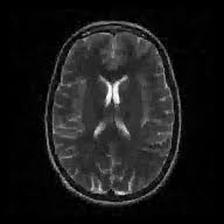

In [ ]:
dataset_name = "MRI_tumor_binary_norm"
split = "test"

# Load dataset (reuse your class)
dataset = MedicalImageDataset(
    dataset_name=dataset_name,
    split=split,
    transform=None  # we will apply preprocess manually
)

# Get one sample
sample = dataset[0]
image_path = sample["path"]
true_label = sample["class"]

print(f"Image path: {image_path}")
print(f"True label: {true_label}")

# Load image
image = Image.open(image_path).convert("RGB")
display(image)


### Prompt variants

In [ ]:
class_prompts_variants = {
    "variant_1_simple": {
        "normal": "A normal brain MRI scan",
        "tumor": "A brain MRI scan with a tumor"
    },
    "variant_2_question": {
        "normal": "This brain MRI shows no tumor",
        "tumor": "This brain MRI shows a tumor"
    },
    "variant_3_clinical": {
        "normal": "A healthy brain MRI without abnormalities",
        "tumor": "A brain MRI demonstrating a mass lesion consistent with tumor"
    },
    "variant_4_binary_explicit": {
        "normal": "No brain tumor is present in this MRI",
        "tumor": "A brain tumor is present in this MRI"
    }
}


### Test clip and biomedclip

In [ ]:
import torch.nn.functional as F

def clip_single_image_test(
    model,
    tokenizer,
    preprocess,
    image,
    prompt_dict,
    model_name="CLIP"
):
    """
    Test one image against multiple text prompts
    """
    model.eval()

    # Preprocess image
    image_tensor = preprocess(image).unsqueeze(0).to(config.DEVICE)

    # Encode image
    with torch.no_grad():
        img_emb = model.encode_image(image_tensor)
        img_emb = F.normalize(img_emb, dim=-1)

    class_names = list(prompt_dict.keys())
    texts = [prompt_dict[c] for c in class_names]

    # Encode text
    with torch.no_grad():
        tokens = tokenizer(texts).to(config.DEVICE)
        txt_emb = model.encode_text(tokens)
        txt_emb = F.normalize(txt_emb, dim=-1)

    # Similarity
    logits = (img_emb @ txt_emb.T).squeeze(0) * 100
    probs = F.softmax(logits, dim=0).cpu().numpy()

    # Print results
    print(f"\n[{model_name}] Prompt set results")
    print("-" * 50)
    for cls, p, logit in zip(class_names, probs, logits.cpu().numpy()):
        print(f"{cls:10s} | prob={p:.4f} | logit={logit:.2f}")

    pred = class_names[int(probs.argmax())]
    print(f"\nPredicted class: {pred}")

    return probs, pred


In [ ]:
!pip install -q open_clip_torch ftfy regex tqdm pillow
!pip install -q transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00


In [ ]:
import open_clip

### Load models

In [ ]:
print("Loading OpenAI CLIP (ViT-B/32)...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='openai'
)
clip_model = clip_model.to(config.DEVICE)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
print("✓ OpenAI CLIP loaded")

# Load BioMedCLIP
print("\nLoading BioMedCLIP...")
try:
    biomedclip_model, _, biomedclip_preprocess = open_clip.create_model_and_transforms(
        'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
    )
    biomedclip_model = biomedclip_model.to(config.DEVICE)
    biomedclip_tokenizer = open_clip.get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
    print("✓ BioMedCLIP loaded")
    biomedclip_available = True
except Exception as e:
    print(f"⚠ BioMedCLIP not available: {e}")
    biomedclip_available = False

print("\nAll available models loaded successfully!")

Loading OpenAI CLIP (ViT-B/32)...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✓ OpenAI CLIP loaded

Loading BioMedCLIP...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✓ BioMedCLIP loaded

All available models loaded successfully!


## Run tests and visualize probabilities

### Openai Clip

In [ ]:
print("=" * 80)
print("OPENAI CLIP – SINGLE IMAGE PROMPT TEST")
print("=" * 80)

for name, prompts in class_prompts_variants.items():
    print(f"\n>>> Prompt variant: {name}")
    o_probs, _pred = clip_single_image_test(
        clip_model,
        clip_tokenizer,
        clip_preprocess,
        image,
        prompts,
        model_name="OpenAI-CLIP"
    )


OPENAI CLIP – SINGLE IMAGE PROMPT TEST

>>> Prompt variant: variant_1_simple

[OpenAI-CLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.4596 | logit=31.63
tumor      | prob=0.5404 | logit=31.79

Predicted class: tumor

>>> Prompt variant: variant_2_question

[OpenAI-CLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.4720 | logit=31.34
tumor      | prob=0.5280 | logit=31.45

Predicted class: tumor

>>> Prompt variant: variant_3_clinical

[OpenAI-CLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.6988 | logit=32.11
tumor      | prob=0.3012 | logit=31.27

Predicted class: normal

>>> Prompt variant: variant_4_binary_explicit

[OpenAI-CLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.4090 | logit=31.24
tumor      | prob=0.5910 | logit=31.61

Predicted class: tumor


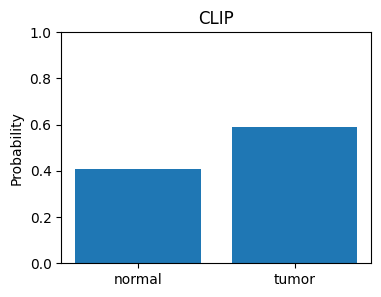

In [ ]:
plot_probs(list(prompts.keys()), o_probs, "CLIP")

## Biomed clip

In [ ]:
if biomedclip_available:
    print("\n" + "=" * 80)
    print("BIOMEDCLIP – SINGLE IMAGE PROMPT TEST")
    print("=" * 80)

    for name, prompts in class_prompts_variants.items():
        print(f"\n>>> Prompt variant: {name}")
        probs, pred = clip_single_image_test(
            biomedclip_model,
            biomedclip_tokenizer,
            biomedclip_preprocess,
            image,
            prompts,
            model_name="BioMedCLIP"
        )



BIOMEDCLIP – SINGLE IMAGE PROMPT TEST

>>> Prompt variant: variant_1_simple

[BioMedCLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.9964 | logit=45.83
tumor      | prob=0.0036 | logit=40.21

Predicted class: normal

>>> Prompt variant: variant_2_question

[BioMedCLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.9863 | logit=40.60
tumor      | prob=0.0137 | logit=36.32

Predicted class: normal

>>> Prompt variant: variant_3_clinical

[BioMedCLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.9999 | logit=45.66
tumor      | prob=0.0001 | logit=36.83

Predicted class: normal

>>> Prompt variant: variant_4_binary_explicit

[BioMedCLIP] Prompt set results
--------------------------------------------------
normal     | prob=0.9922 | logit=42.71
tumor      | prob=0.0078 | logit=37.86

Predicted class: normal


In [ ]:
import matplotlib.pyplot as plt

def plot_probs(class_names, probs, title):
    plt.figure(figsize=(4, 3))
    plt.bar(class_names, probs)
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel("Probability")
    plt.show()


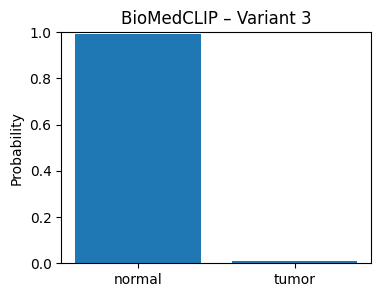

In [ ]:
plot_probs(list(prompts.keys()), probs, "BioMedCLIP – Variant 3")
